<a href="https://colab.research.google.com/github/PuriwatSiri/CS461_xray_pneumonia/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"teeratatsalak","key":"bb632b29e4af2b8c2f233b0b0940f8e1"}'}

 Data Preprocessing

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

!unzip chest-xray-pneumonia.zip

!rm chest-xray-pneumonia.zip

เอาต์พุตของการสตรีมมีการตัดเหลือเพียง 5000 บรรทัดสุดท้าย
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  infl

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = 'chest_xray/train'

test_dir  = 'chest_xray/test'

IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)


test_gen = ImageDataGenerator(rescale=1./255)


print("Loading Training Data:")
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)


print("Loading Validation Data:")
val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


print("Loading Test Data:")
test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Loading Training Data:
Found 4173 images belonging to 2 classes.
Loading Validation Data:
Found 1043 images belonging to 2 classes.
Loading Test Data:
Found 624 images belonging to 2 classes.


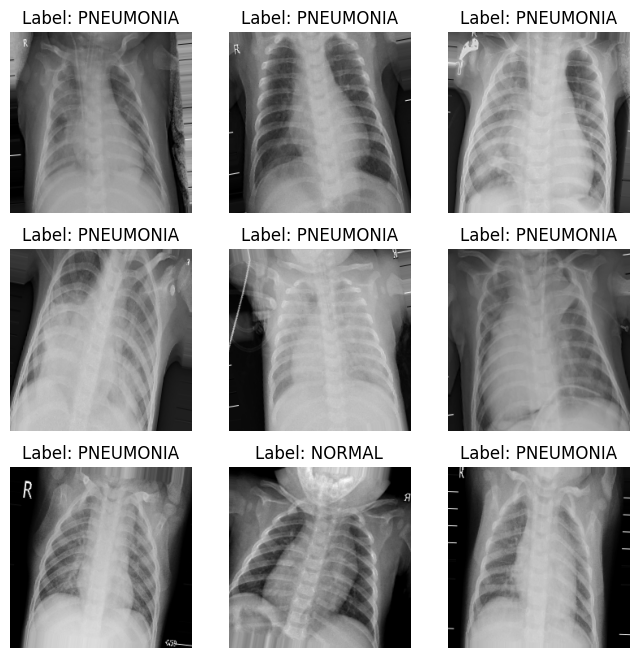

In [ ]:
imgs, labels = next(train_data)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[i])
    plt.title("Label: " + ("PNEUMONIA" if labels[i]==1 else "NORMAL"))
    plt.axis('off')
plt.show()


Baseline Model

In [ ]:
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base.trainable = False

model = tf.keras.Sequential([
    base,
    tf.keras.layers.GlobalMaxPooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 137s 918ms/step - accuracy: 0.7661 - loss: 0.7858 - val_accuracy: 0.9338 - val_loss: 0.1751
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 94s 717ms/step - accuracy: 0.8931 - loss: 0.3198 - val_accuracy: 0.9482 - val_loss: 0.1523
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 93s 709ms/step - accuracy: 0.9138 - loss: 0.2601 - val_accuracy: 0.9492 - val_loss: 0.1224
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 790ms/step - accuracy: 0.9325 - loss: 0.2123 - val_accuracy: 0.9453 - val_loss: 0.1577
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.9482 - loss: 0.1536 - val_accuracy: 0.9607 - val_loss: 0.1152
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 731ms/step - accuracy: 0.9418 - loss: 0.1562 - val_accuracy: 0.9511 - val_loss: 0.1334
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 94s 716ms/step - accuracy: 0.9495 - loss: 0.1379 - val_accuracy: 0.9569 - val_loss: 0.1311
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 93s 709ms/step - accuracy: 0.9444 - loss

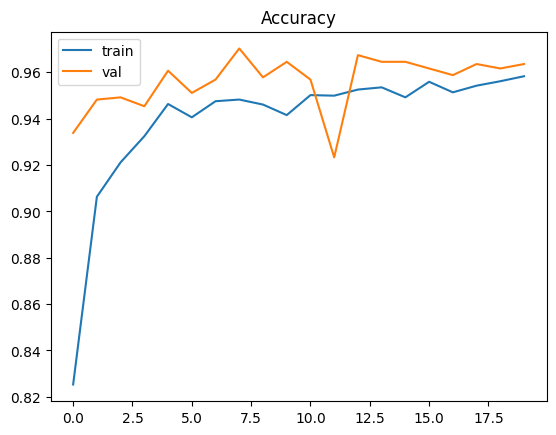

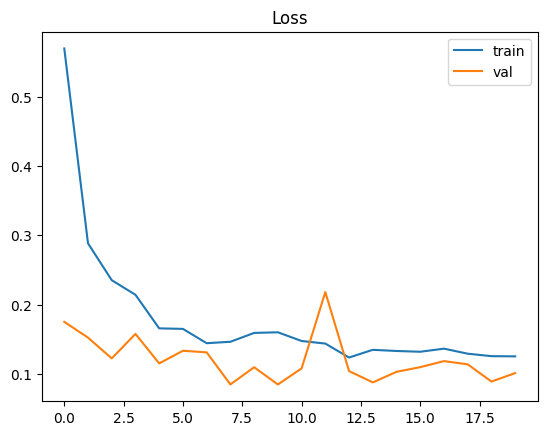

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'val'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

pred_baseline = model.predict(test_data)
pred_baseline = (pred_baseline > 0.5).astype(int)

cm_baseline = confusion_matrix(test_data.classes, pred_baseline)
acc_baseline = accuracy_score(test_data.classes, pred_baseline)

print(f"Confusion Matrix (Baseline):\n{cm_baseline}")
print("\nClassification Report (Baseline):\n")
print(classification_report(test_data.classes, pred_baseline, target_names=['NORMAL','PNEUMONIA']))
print(f"Baseline Model Accuracy: {acc_baseline:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 806ms/step
Confusion Matrix (Baseline):
[[143  91]
 [  5 385]]

Classification Report (Baseline):

              precision    recall  f1-score   support

      NORMAL       0.97      0.61      0.75       234
   PNEUMONIA       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.80      0.82       624
weighted avg       0.87      0.85      0.84       624

Baseline Model Accuracy: 0.8462


# **Fine-Tuned-Model**


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

def create_transfer_learning_model(input_shape=(224, 224, 3)):

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    base_model.trainable = True
    set_trainable = False
    for layer in base_model.layers:
      if layer.name == 'block5_conv1':
        set_trainable = True
      if set_trainable:
        layer.trainable = True
      else:
        layer.trainable = False


    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')

   ])
    model.compile(loss='binary_crossentropy',
                  optimizer=optimizers.Adam(learning_rate=1e-5),
                  metrics=['accuracy'])
    return model

transfer_model = create_transfer_learning_model()
transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 13,502,465 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


history_vgg = transfer_model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stopping]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 921ms/step - accuracy: 0.8484 - loss: 0.3413 - val_accuracy: 0.9453 - val_loss: 0.1359
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 798ms/step - accuracy: 0.9513 - loss: 0.1284 - val_accuracy: 0.9684 - val_loss: 0.0842
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 776ms/step - accuracy: 0.9627 - loss: 0.0980 - val_accuracy: 0.9607 - val_loss: 0.1042
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 767ms/step - accuracy: 0.9694 - loss: 0.0851 - val_accuracy: 0.9770 - val_loss: 0.0643
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 772ms/step - accuracy: 0.9744 - loss: 0.0741 - val_accuracy: 0.9818 - val_loss: 0.0599
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 772ms/step - accuracy: 0.9809 - loss: 0.0712 - val_accuracy: 0.9712 - val_loss: 0.0649
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 771ms/step - accuracy: 0.9767 - loss: 0.0645 - val_accuracy: 0.9770 - val_loss: 0.0595
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 774ms/step - accuracy: 0.9802 -

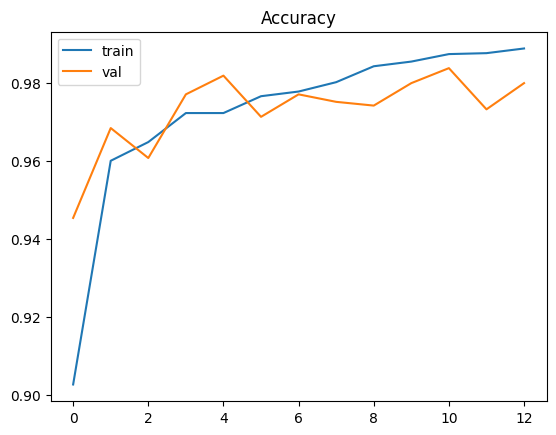

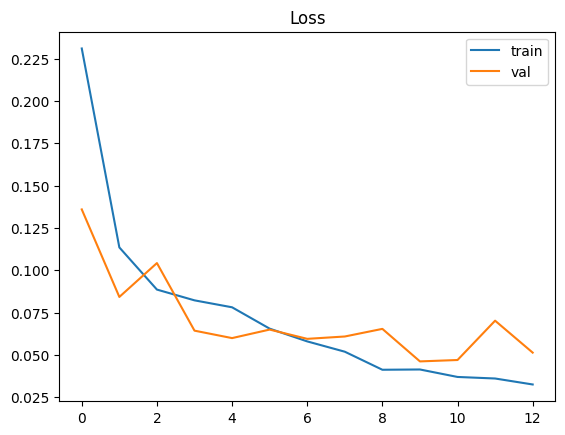

In [ ]:
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'val'])
plt.show()

plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

pred_vgg = transfer_model.predict(test_data)
pred_vgg = (pred_vgg > 0.5).astype(int)

cm_vgg = confusion_matrix(test_data.classes, pred_vgg)
acc_vgg = accuracy_score(test_data.classes, pred_vgg)

print(f"Confusion Matrix (Fine-tuned):\n{cm_vgg}")
print("\nClassification Report (Fine-tuned):\n")
print(classification_report(test_data.classes, pred_vgg, target_names=['NORMAL','PNEUMONIA']))
print(f"Fine-tuned Model Accuracy: {acc_vgg:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 613ms/step
Confusion Matrix (Fine-tuned):
[[168  66]
 [  3 387]]

Classification Report (Fine-tuned):

              precision    recall  f1-score   support

      NORMAL       0.98      0.72      0.83       234
   PNEUMONIA       0.85      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.92      0.86      0.87       624
weighted avg       0.90      0.89      0.88       624

Fine-tuned Model Accuracy: 0.8894


# Final **Result**

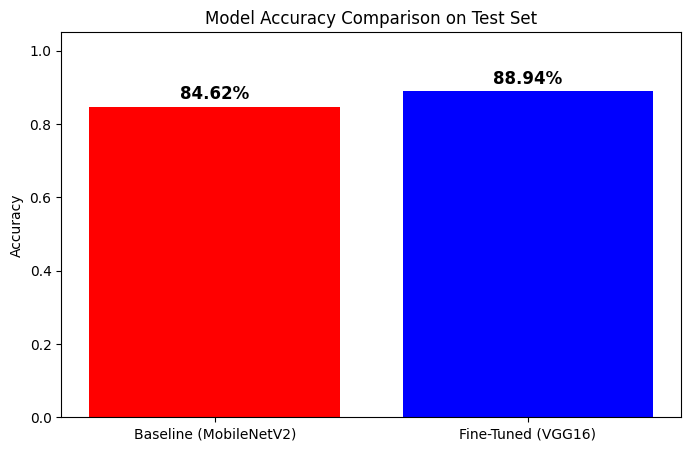

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = ['Baseline (MobileNetV2)', 'Fine-Tuned (VGG16)']
accuracies = [acc_baseline, acc_vgg]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies, color=['red', 'blue'])

plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison on Test Set')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             f"{yval:.2%}",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

# **ส่วนติดต่อผู้ใช้ หรือหน้าเว็บไซต์**

In [ ]:
!pip install fastapi uvicorn pyngrok python-multipart nest-asyncio

import os
import io
import numpy as np
import tensorflow as tf
from PIL import Image
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import HTMLResponse
import nest_asyncio
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "2x7awep0CCMO2xfoIbTKhwkqo91_6zQndsNk5mwwnqGAKsRSc"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

try:
    model = transfer_model
    print("Loaded model from memory.")

except NameError:
    try:
        model = tf.keras.models.load_model('my_model.h5')
        print("Loaded model from file.")
    except:
        print("Error: Model not found.")
        model = None

app = FastAPI()

html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>AI ตรวจปอดอักเสบ</title>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <script src="https://cdn.tailwindcss.com"></script>
    <link href="https://fonts.googleapis.com/css2?family=Sarabun:wght@300;400;600&display=swap" rel="stylesheet">
    <style> body { font-family: 'Sarabun', sans-serif; } </style>
</head>
<body class="bg-slate-100 min-h-screen flex flex-col items-center justify-center p-4">
    <div class="absolute top-4 right-4 bg-white p-4 rounded-xl shadow-lg border border-slate-200 text-sm opacity-90">
        <div class="flex items-center gap-2 mb-1">
            <span class="text-black">ค่ามากกว่า 0.5 เป็นโรคปอดบวม</span>
        </div>
        <div class="flex items-center gap-2">
            <span class="text-black">ค่าน้อยกว่าหรือเท่ากับ 0.5 เป็นปอดปกติ</span>
        </div>
    </div>

    <div class="bg-white p-8 rounded-2xl shadow-xl w-full max-w-md text-center">
        <h1 class="text-3xl font-bold text-blue-600 mb-2">ตรวจโรคปอดบวมจาก AI</h1>
        <p class="text-gray-500 mb-6">อัปโหลดภาพ X-Ray ปอด</p>

        <div class="border-2 border-dashed border-gray-300 rounded-xl p-6 mb-4 cursor-pointer hover:bg-blue-50 transition relative" onclick="document.getElementById('fileInput').click()">
            <input type="file" id="fileInput" class="hidden" accept="image/*" onchange="previewImage(event)">
            <div id="placeholder" class="text-gray-400">
                <svg class="w-12 h-12 mx-auto mb-2" fill="none" stroke="currentColor" viewBox="0 0 24 24"><path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M4 16l4.586-4.586a2 2 0 012.828 0L16 16m-2-2l1.586-1.586a2 2 0 012.828 0L20 14m-6-6h.01M6 20h12a2 2 0 002-2V6a2 2 0 00-2-2H6a2 2 0 00-2 2v12a2 2 0 002 2z"></path></svg>
                <p>แตะเพื่อเลือกรูปภาพ</p>
            </div>
            <img id="preview" class="hidden w-full h-48 object-contain rounded-lg z-10 relative">
        </div>

        <button onclick="uploadAndPredict()" id="btnPredict" class="w-full bg-blue-600 text-white font-bold py-3 rounded-xl hover:bg-blue-700 transition disabled:opacity-50" disabled>
            วิเคราะห์ผล
        </button>

        <div id="resultArea" class="hidden mt-6 p-4 bg-slate-50 rounded-xl border border-slate-200">
            <p class="text-sm text-gray-500 mb-1">ผลการตรวจ:</p>
            <h2 id="resultText" class="text-2xl font-bold text-gray-800"></h2>
            <div class="w-full bg-gray-200 rounded-full h-2.5 mt-3">
                <div id="confBar" class="bg-blue-600 h-2.5 rounded-full" style="width: 0%"></div>
            </div>
            <p id="confText" class="text-xs text-gray-500 mt-1 text-right"></p>
        </div>
    </div>

    <script>
        let selectedFile = null;
        function previewImage(event) {
            selectedFile = event.target.files[0];
            if (selectedFile) {
                document.getElementById('placeholder').classList.add('hidden');
                const img = document.getElementById('preview');
                img.src = URL.createObjectURL(selectedFile);
                img.classList.remove('hidden');
                document.getElementById('btnPredict').disabled = false;
                document.getElementById('resultArea').classList.add('hidden');
            }
        }

        async function uploadAndPredict() {
            if (!selectedFile) return;

            const btn = document.getElementById('btnPredict');
            btn.innerText = "กำลังประมวลผล...";
            btn.disabled = true;

            const formData = new FormData();
            formData.append("file", selectedFile);

            try {
                const response = await fetch("/predict", { method: "POST", body: formData });
                const data = await response.json();

                const resArea = document.getElementById('resultArea');
                const resText = document.getElementById('resultText');
                const confBar = document.getElementById('confBar');
                const confText = document.getElementById('confText');

                resArea.classList.remove('hidden');
                resText.innerText = data.label;
                resText.style.color = data.color;

                const percent = parseFloat(data.score) * 100;
                confBar.style.width = percent + "%";
                confBar.className = `h-2.5 rounded-full ${data.label.includes('ปอดบวม') ? 'bg-red-500' : 'bg-green-500'}`;
                confText.innerText = `ความมั่นใจ: ${data.score}`;

            } catch (error) {
                alert("เกิดข้อผิดพลาด: " + error);
            } finally {
                btn.innerText = "วิเคราะห์ผล";
                btn.disabled = false;
            }
        }
    </script>
</body>
</html>
"""

@app.get("/")
async def index():
    return HTMLResponse(content=html_content)


@app.post("/predict")
async def predict_api(file: UploadFile = File(...)):
    if model is None:
        return {"label": "Model Error", "score": "0.00", "color": "gray"}

    image_data = await file.read()
    img = Image.open(io.BytesIO(image_data)).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)

    prediction = model.predict(img_array)
    score = float(prediction[0][0])

    if score > 0.5:
        return {"label": "PNEUMONIA (ปอดบวม)", "score": f"{score:.4f}", "color": "#ef4444"}
    else:
        return {"label": "NORMAL (ปกติ)", "score": f"{1-score:.4f}", "color": "#22c55e"}

nest_asyncio.apply()
ngrok.kill()

public_url = ngrok.connect(8000).public_url
print(f"\nเว็บของคุณออนไลน์แล้วที่: {public_url}\n")

from uvicorn import Config, Server

config = Config(app=app, host="0.0.0.0", port=8000)
server = Server(config=config)

await server.serve()


Loaded model from memory.


INFO:     Started server process [317]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



เว็บของคุณออนไลน์แล้วที่: https://85bb1a1c7800.ngrok-free.app

INFO:     2001:fb1:ee:80b8:205e:dfeb:49ef:d2c8:0 - "GET / HTTP/1.1" 200 OK
INFO:     2001:fb1:ee:80b8:205e:dfeb:49ef:d2c8:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     2001:fb1:ee:80b8:205e:dfeb:49ef:d2c8:0 - "GET / HTTP/1.1" 200 OK


In [ ]:
transfer_model.save('pneumonia_vgg16_model.h5')
print("บันทึกโมเดล VGG16 เรียบร้อยแล้ว")



In [ ]:
from google.colab import files

files.download('pneumonia_vgg16_model.h5')